# Etape 2.2 — Face Match : Selfie vs Photo ID

Ce notebook implémente la vérification biométrique entre un selfie et la photo extraite d'une pièce d'identité.

**Pipeline :**
1. La photo ID est fournie par l'étape 2.1 (crop du visage sur le document)
2. L'utilisateur fournit un selfie
3. YOLO détecte et recadre le visage dans le selfie
4. ArcFace extrait les embeddings des deux visages et calcule leur similarité
5. Résultat : MATCH ou NO MATCH

> Executer les cellules dans l'ordre, de haut en bas.

---
## 1. Installation des librairies

In [32]:
# Toutes les dependances du projet
!pip install ultralytics insightface onnxruntime opencv-python-headless pillow pillow-heif huggingface_hub tqdm scikit-learn -q
print('Installation terminee.')

Installation terminee.


---
## 2. Imports

In [33]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image, ImageOps
from pillow_heif import register_heif_opener
from google.colab import files
from ultralytics import YOLO
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

# Support des photos iPhone (format HEIC)
register_heif_opener()

print('Imports OK.')

Imports OK.


---
## 3. Chargement des modeles

- **YOLOv8-Face** : detection du visage dans le selfie
- **ArcFace (buffalo_l)** : extraction des embeddings faciaux et comparaison

Le premier lancement telecharge automatiquement les poids (~300MB).

In [34]:
from insightface.app import FaceAnalysis
from huggingface_hub import hf_hub_download

# Chargement de YOLO specialise detection de visages
print('Chargement de YOLO...')
chemin_yolo = hf_hub_download(
    repo_id='arnabdhar/YOLOv8-Face-Detection',
    filename='model.pt'
)
yolo_model = YOLO(chemin_yolo)
print('YOLO charge.')

# Chargement d'ArcFace via insightface (buffalo_l = ResNet50, 99.8% sur LFW)
print('Chargement d ArcFace (buffalo_l)...')
app_arcface = FaceAnalysis(
    name='buffalo_l',
    providers=['CPUExecutionProvider']  # remplacer par CUDAExecutionProvider si GPU disponible
)
app_arcface.prepare(ctx_id=-1, det_size=(640, 640))
print('ArcFace charge.')

Chargement de YOLO...
YOLO charge.
Chargement d ArcFace (buffalo_l)...
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition 

---
## 4. Pretraitement des images

Fonction de normalisation appliquee a toutes les images avant traitement.
Gere : correction d'orientation EXIF, conversion de format, transparence, redimensionnement.

In [35]:
TAILLE_MAX = 1920  # pixels, au-dela l'image est redimensionnee

def pretraiter_image(chemin_image: str) -> np.ndarray:
    """
    Charge et normalise une image pour YOLO et ArcFace.
    Retourne un tableau numpy BGR.
    """
    if not Path(chemin_image).exists():
        raise FileNotFoundError(f'Fichier introuvable : {chemin_image}')

    try:
        img_pil = Image.open(chemin_image)
    except Exception:
        raise ValueError('Image corrompue ou format non supporte.')

    # Correction de l'orientation (photos smartphone souvent mal orientees)
    img_pil = ImageOps.exif_transpose(img_pil)

    # Conversion en RGB 3 canaux selon le mode detecte
    if img_pil.mode == 'RGBA':
        # PNG avec transparence : fond transparent remplace par blanc
        fond_blanc = Image.new('RGB', img_pil.size, (255, 255, 255))
        fond_blanc.paste(img_pil, mask=img_pil.split()[3])
        img_pil = fond_blanc
    elif img_pil.mode in ('L', 'LA', 'P'):
        img_pil = img_pil.convert('RGB')
    else:
        img_pil = img_pil.convert('RGB')

    # Redimensionnement si l'image depasse la taille maximale
    if max(img_pil.size) > TAILLE_MAX:
        img_pil.thumbnail((TAILLE_MAX, TAILLE_MAX), Image.LANCZOS)

    # Conversion vers BGR (format attendu par OpenCV et YOLO)
    img_bgr = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)
    return img_bgr

print('Fonction de pretraitement definie.')

Fonction de pretraitement definie.


---
## 5. Detection du visage (YOLO)

YOLO localise le visage dans une image et retourne uniquement la zone du visage.
Utilise pour recadrer le selfie avant extraction d'embedding.

In [36]:
SEUIL_CONFIANCE_YOLO = 0.5   # confiance minimale pour valider une detection
TAILLE_MIN_VISAGE    = 60    # taille minimale en pixels pour qu'un visage soit exploitable

def detecter_visage_yolo(img_bgr: np.ndarray) -> np.ndarray:
    """
    Detecte le visage dans une image et retourne le crop du visage.
    Si plusieurs visages sont detectes, selectionne le plus grand.
    Retourne un tableau numpy BGR.
    """
    resultats   = yolo_model(img_bgr, conf=SEUIL_CONFIANCE_YOLO, verbose=False, device='cpu')
    boites      = resultats[0].boxes

    if boites is None or len(boites) == 0:
        raise ValueError('Aucun visage detecte. Verifier que le visage est bien visible et centre.')

    boites_xyxy = boites.xyxy.cpu().numpy()
    boites_conf = boites.conf.cpu().numpy()

    # Selection du visage le plus grand (supposé le plus proche de la camera)
    surfaces      = [(x2-x1)*(y2-y1) for x1,y1,x2,y2 in boites_xyxy]
    idx           = int(np.argmax(surfaces))
    x1,y1,x2,y2  = [int(v) for v in boites_xyxy[idx]]
    confiance     = float(boites_conf[idx])

    largeur = x2 - x1
    hauteur = y2 - y1

    if largeur < TAILLE_MIN_VISAGE or hauteur < TAILLE_MIN_VISAGE:
        raise ValueError(f'Visage trop petit ({largeur}x{hauteur}px). Rapprocher la camera.')

    # Marge de 20% autour du visage pour eviter de le couper
    h_img, w_img = img_bgr.shape[:2]
    x1 = max(0, x1 - int(largeur * 0.20))
    y1 = max(0, y1 - int(hauteur * 0.20))
    x2 = min(w_img, x2 + int(largeur * 0.20))
    y2 = min(h_img, y2 + int(hauteur * 0.20))

    print(f'Visage detecte | Confiance : {confiance:.2%} | Taille : {largeur}x{hauteur}px')
    return img_bgr[y1:y2, x1:x2]

print('Fonction de detection YOLO definie.')

Fonction de detection YOLO definie.


---
## 6. Extraction d'embedding ArcFace

ArcFace transforme un visage en un vecteur de 512 nombres (embedding) qui encode l'identite.
Deux visages de la meme personne produisent des embeddings proches.

In [37]:
def extraire_embedding(img_bgr: np.ndarray) -> np.ndarray:
    """
    Detecte le visage dans l'image et extrait son embedding ArcFace.
    Retourne un vecteur numpy normalise de 512 dimensions.
    """
    faces = app_arcface.get(img_bgr)

    if not faces:
        raise ValueError('Aucun visage detecte pour l extraction d embedding.')

    # Si plusieurs visages, on prend celui avec le meilleur score de detection
    meilleur  = max(faces, key=lambda f: f.det_score)
    return meilleur.normed_embedding  # vecteur L2-normalise de 512 dimensions

print('Fonction d extraction ArcFace definie.')

Fonction d extraction ArcFace definie.


---
## 7. Comparaison et decision

La similarite entre deux embeddings est mesuree par la distance cosine.
- Distance proche de 0 : meme personne
- Distance proche de 2 : personnes differentes

**Deux seuils sont definis :**
- `SEUIL_DECISION` (0.40) : seuil strict utilise pour la demo KYC
- `SEUIL_EVALUATION` (0.70) : seuil optimal calibre par EER sur le dataset de test

In [38]:
# Seuil strict pour la verification unitaire (demo KYC)
# A ce seuil, le systeme prefere rejeter une vraie personne plutot qu'accepter un imposteur
SEUIL_DECISION    = 0.40

# Seuil optimal calibre par EER sur le dataset Kaggle
SEUIL_EVALUATION  = 0.70

def comparer_visages(emb1: np.ndarray, emb2: np.ndarray, seuil: float = None) -> dict:
    """
    Compare deux embeddings ArcFace et retourne la decision.
    Retourne un dictionnaire avec : decision, score, distance, confiance.
    """
    seuil     = seuil or SEUIL_DECISION
    similarite = float(np.dot(emb1, emb2))       # produit scalaire = cosine similarity (embeddings L2-normalises)
    distance   = 1.0 - similarite                 # distance cosine [0, 2]
    score      = float(np.clip(similarite * 100, 0, 100))
    est_match  = distance < seuil

    # Niveau de confiance selon la marge au seuil
    marge = abs(distance - seuil)
    if marge >= 0.15:
        confiance = 'HAUTE'
    elif marge >= 0.05:
        confiance = 'MOYENNE'
    else:
        confiance = 'FAIBLE'

    return {
        'est_match' : est_match,
        'score'     : round(score, 1),
        'distance'  : round(distance, 4),
        'confiance' : confiance,
        'seuil'     : seuil
    }

print('Fonction de comparaison definie.')

Fonction de comparaison definie.


---
## 8. Affichage du resultat

In [39]:
def afficher_resultat(img_selfie: np.ndarray, img_id: np.ndarray, resultat: dict):
    """
    Affiche les deux visages cote a cote avec le resultat de la comparaison.
    """
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    axes[0].imshow(cv2.cvtColor(img_selfie, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Selfie', fontsize=13, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(cv2.cvtColor(img_id, cv2.COLOR_BGR2RGB))
    axes[1].set_title('Photo ID', fontsize=13, fontweight='bold')
    axes[1].axis('off')

    if resultat['est_match']:
        titre   = f"MEME PERSONNE - Score : {resultat['score']}% - Confiance : {resultat['confiance']}"
        couleur = '#1D9E75'
    else:
        titre   = f"PERSONNES DIFFERENTES - Score : {resultat['score']}% - Confiance : {resultat['confiance']}"
        couleur = '#D85A30'

    fig.suptitle(titre, fontsize=12, color=couleur, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*45}")
    print(f"  Resultat  : {'MATCH' if resultat['est_match'] else 'NO MATCH'}")
    print(f"  Score     : {resultat['score']}%")
    print(f"  Distance  : {resultat['distance']} (seuil : {resultat['seuil']})")
    print(f"  Confiance : {resultat['confiance']}")
    print(f"{'='*45}")

print('Fonction d affichage definie.')

Fonction d affichage definie.


---
## 9. Verification unitaire (demo KYC)

Uploader la photo ID fournie par l'etape 2.1, puis le selfie de l'utilisateur.
Le seuil strict `SEUIL_DECISION = 0.40` est applique.

Upload de la photo ID (tentative 1/3)...


Saving photo-identite-titre-sejour.png to photo-identite-titre-sejour.png
Visage detecte | Confiance : 91.64% | Taille : 174x226px

Upload du selfie (tentative 1/3)...


Saving photo-identite-agree-photographe-professionnel-paris-13-studio-destel-femme.webp to photo-identite-agree-photographe-professionnel-paris-13-studio-destel-femme.webp
Visage detecte | Confiance : 94.61% | Taille : 187x249px

Extraction des embeddings ArcFace...


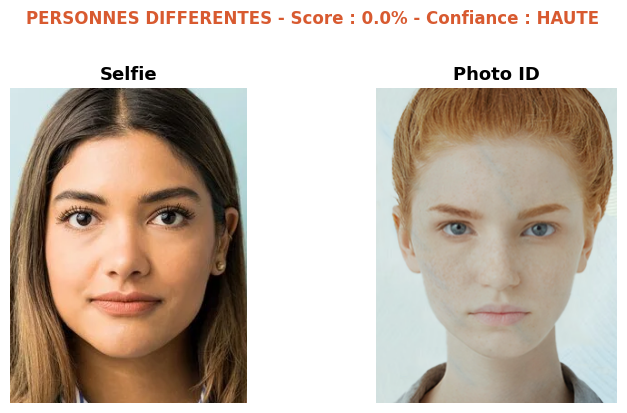


  Resultat  : NO MATCH
  Score     : 0.0%
  Distance  : 1.0499 (seuil : 0.4)
  Confiance : HAUTE


In [40]:
def pipeline_verification():
    """
    Pipeline de verification avec relance automatique en cas de probleme.
    """
    MAX_TENTATIVES = 3

    # --- Upload et validation de la photo ID ---
    crop_id = None
    tentatives = 0
    while crop_id is None and tentatives < MAX_TENTATIVES:
        try:
            print(f'Upload de la photo ID (tentative {tentatives + 1}/{MAX_TENTATIVES})...')
            fichiers_id     = files.upload()
            chemin_photo_id = list(fichiers_id.keys())[0]
            img_id          = pretraiter_image(chemin_photo_id)
            crop_id         = detecter_visage_yolo(img_id)
        except Exception as e:
            tentatives += 1
            print(f'Probleme detecte : {e}')
            if tentatives < MAX_TENTATIVES:
                print('Veuillez uploader une nouvelle photo ID.')
            else:
                print('Nombre maximum de tentatives atteint pour la photo ID.')
                return

    # --- Upload et validation du selfie ---
    crop_selfie = None
    tentatives  = 0
    while crop_selfie is None and tentatives < MAX_TENTATIVES:
        try:
            print(f'\nUpload du selfie (tentative {tentatives + 1}/{MAX_TENTATIVES})...')
            fichiers_selfie = files.upload()
            chemin_selfie   = list(fichiers_selfie.keys())[0]
            img_selfie      = pretraiter_image(chemin_selfie)
            crop_selfie     = detecter_visage_yolo(img_selfie)
        except Exception as e:
            tentatives += 1
            print(f'Probleme detecte : {e}')
            if tentatives < MAX_TENTATIVES:
                print('Veuillez uploader un nouveau selfie.')
                print('Conseils : visage de face, bien eclaire, regard vers la camera.')
            else:
                print('Nombre maximum de tentatives atteint pour le selfie.')
                return

    # --- Extraction des embeddings et comparaison ---
    print('\nExtraction des embeddings ArcFace...')
    emb_selfie = extraire_embedding(img_selfie)
    emb_id     = extraire_embedding(img_id)

    resultat = comparer_visages(emb_selfie, emb_id, seuil=SEUIL_DECISION)
    afficher_resultat(crop_selfie, crop_id, resultat)


# Lancement du pipeline
pipeline_verification()

---
## 10. Telechargement du dataset Kaggle

Dataset : `tapakah68/selfies-id-images-dataset`

**Configuration requise (une seule fois) :**
1. Aller sur kaggle.com -> Account -> API -> Create New Token
2. Dans Colab, cliquer sur l'icone cle (secrets) dans la barre de gauche
3. Ajouter `KAGGLE_USERNAME` et `KAGGLE_KEY` avec les valeurs du fichier kaggle.json

In [41]:
import os
from google.colab import userdata

# Recuperation des credentials depuis les secrets Colab (ne jamais mettre en clair dans le code)
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY']      = userdata.get('KAGGLE_KEY')

!pip install kaggle -q
print('API Kaggle configuree.')

# Telechargement du dataset directement dans l'environnement Colab
print('Telechargement du dataset...')
!kaggle datasets download -d tapakah68/selfies-id-images-dataset -p ./dataset --unzip -q
print('Dataset disponible dans ./dataset')

# Verification de la structure
for dossier in Path('./dataset').iterdir():
    nb = len(list(dossier.glob('*'))) if dossier.is_dir() else 0
    print(f'  {dossier.name} -> {nb} elements')

API Kaggle configuree.
Telechargement du dataset...
Dataset URL: https://www.kaggle.com/datasets/tapakah68/selfies-id-images-dataset
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
Dataset disponible dans ./dataset
  Selfies ID Images dataset -> 2 elements
  selfie_id.csv -> 0 elements


---
## 11. Generation des paires de test

Construction de l'echantillon de test a partir du dataset :
- **Paires positives** : photo ID + selfie de la meme personne (label = 1)
- **Paires negatives** : photo ID d'une personne + selfie d'une autre (label = 0)

Chaque personne contribue avec 3 selfies differents pour augmenter la diversite.

In [42]:
GRAINE_ALEATOIRE = 42  # graine fixee pour la reproductibilite des resultats
DOSSIER_DATASET  = Path('./dataset/Selfies ID Images dataset')

def trouver_dossiers() -> dict:
    """Construit un mapping SetId -> chemin du dossier personne."""
    mapping = {}
    for chemin_id in DOSSIER_DATASET.rglob('ID_1.jpg'):
        dossier = chemin_id.parent
        set_id  = dossier.name.split('_age_')[0]
        mapping[set_id] = dossier
    return mapping

mapping_dossiers = trouver_dossiers()
set_ids          = list(mapping_dossiers.keys())
print(f'Personnes disponibles : {len(set_ids)}')

def generer_paires(graine: int) -> pd.DataFrame:
    """Genere les paires positives et negatives de maniere equilibree."""
    rng = np.random.default_rng(graine)

    # Paires positives : 3 selfies differents par personne avec sa photo ID
    paires_positives = []
    for set_id in set_ids:
        dossier   = mapping_dossiers[set_id]
        chemin_id = dossier / 'ID_1.jpg'
        for num_selfie in ['Selfie_1.jpg', 'Selfie_2.jpg', 'Selfie_3.jpg']:
            chemin_selfie = dossier / num_selfie
            if chemin_id.exists() and chemin_selfie.exists():
                paires_positives.append({'selfie_path': str(chemin_selfie), 'id_path': str(chemin_id), 'label': 1})

    print(f'Paires positives : {len(paires_positives)}')

    # Paires negatives : meme nombre que les positives pour un dataset equilibre
    paires_negatives = []
    nb_negatif       = len(paires_positives)
    tentatives       = 0
    while len(paires_negatives) < nb_negatif and tentatives < nb_negatif * 10:
        id_a, id_b = rng.choice(set_ids, size=2, replace=False)
        if id_a != id_b:
            c_id  = mapping_dossiers[id_a] / 'ID_1.jpg'
            c_sel = mapping_dossiers[id_b] / 'Selfie_1.jpg'
            if c_id.exists() and c_sel.exists():
                paires_negatives.append({'selfie_path': str(c_sel), 'id_path': str(c_id), 'label': 0})
        tentatives += 1

    print(f'Paires negatives : {len(paires_negatives)}')

    df = pd.DataFrame(paires_positives + paires_negatives)
    return df.sample(frac=1, random_state=graine).reset_index(drop=True)

df_paires = generer_paires(GRAINE_ALEATOIRE)
df_paires.to_csv('./pairs.csv', index=False)

print(f'\npairs.csv genere : {len(df_paires)} paires')
print(f'  Match    : {int(df_paires["label"].sum())}')
print(f'  No-match : {int((df_paires["label"] == 0).sum())}')
df_paires.head()

Personnes disponibles : 29
Paires positives : 87
Paires negatives : 87

pairs.csv genere : 174 paires
  Match    : 87
  No-match : 87


,selfie_path,id_path,label
0,dataset/Selfies ID Images dataset/11_sets_Hisp...,dataset/Selfies ID Images dataset/18_sets_ Cau...,0
1,dataset/Selfies ID Images dataset/18_sets_ Cau...,dataset/Selfies ID Images dataset/11_sets_Hisp...,0
2,dataset/Selfies ID Images dataset/18_sets_ Cau...,dataset/Selfies ID Images dataset/11_sets_Hisp...,0
3,dataset/Selfies ID Images dataset/18_sets_ Cau...,dataset/Selfies ID Images dataset/18_sets_ Cau...,0
4,dataset/Selfies ID Images dataset/18_sets_ Cau...,dataset/Selfies ID Images dataset/18_sets_ Cau...,0


---
## 12. Verification visuelle des paires

Avant d'evaluer le modele, on verifie visuellement que les paires generees sont correctes.
Chaque ligne doit montrer la meme personne a gauche (selfie) et a droite (photo ID).

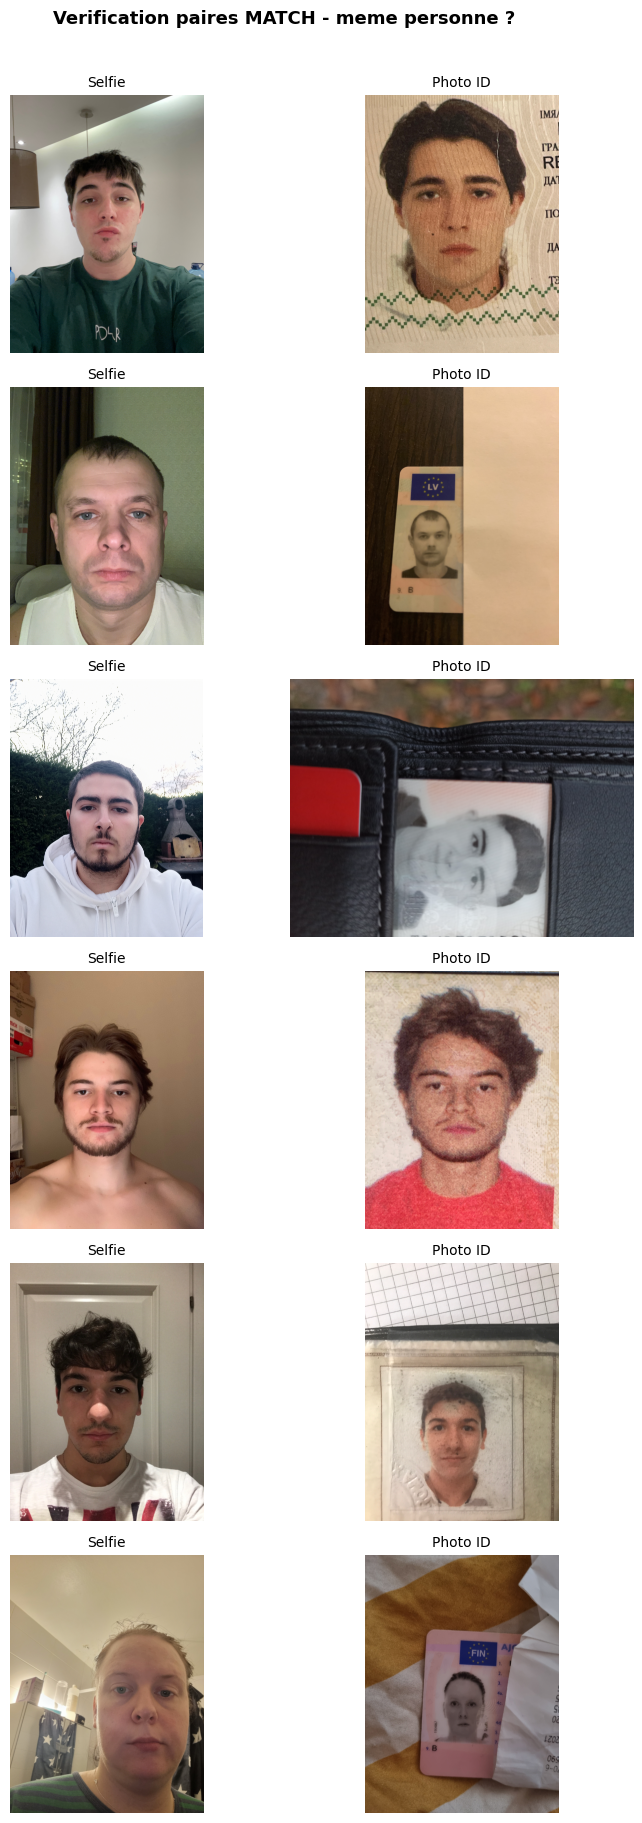

In [43]:
df_paires    = pd.read_csv('./pairs.csv')
paires_match = df_paires[df_paires['label'] == 1].sample(6, random_state=42)

fig, axes = plt.subplots(6, 2, figsize=(8, 18))
fig.suptitle('Verification paires MATCH - meme personne ?', fontsize=13, fontweight='bold', y=1.01)

for idx, (_, ligne) in enumerate(paires_match.iterrows()):
    img_s = cv2.cvtColor(cv2.imread(ligne['selfie_path']), cv2.COLOR_BGR2RGB)
    img_i = cv2.cvtColor(cv2.imread(ligne['id_path']),     cv2.COLOR_BGR2RGB)
    axes[idx, 0].imshow(img_s)
    axes[idx, 0].set_title('Selfie', fontsize=10)
    axes[idx, 0].axis('off')
    axes[idx, 1].imshow(img_i)
    axes[idx, 1].set_title('Photo ID', fontsize=10)
    axes[idx, 1].axis('off')

plt.tight_layout()
plt.show()

---
## 13. Evaluation des performances

Le pipeline est execute sur toutes les paires du dataset de test avec le seuil strict `SEUIL_DECISION = 0.40`.

Ce seuil correspond a notre contexte KYC : le systeme prefere rejeter une vraie personne plutot qu'accepter un imposteur. Le taux de rejet (FNMR) sera donc plus eleve qu'avec le seuil EER optimal (0.70), ce qui est un choix delibere de securite.

**Metriques calculees :**
- **AUC-ROC** : performance globale independante du seuil (objectif >= 0.90)
- **EER** : taux d'erreur a l'equilibre, indique le seuil optimal du modele
- **FMR** : taux de faux match au seuil 0.40 (imposteur accepte)
- **FNMR** : taux de faux non-match au seuil 0.40 (vraie personne rejetee, eleve par choix)

Evaluation sur 174 paires avec seuil = 0.4...


100%|██████████| 174/174 [06:40<00:00,  2.30s/it]


Termine : 174 paires traitees, 0 ignorees

  RESULTATS - Seuil KYC strict = 0.4
  AUC-ROC  : 1.0000   (performance globale du modele)
  EER      : 0.0000   (seuil optimal du modele = 0.7025)
  Accuracy : 0.5920   (au seuil strict 0.4)
  FMR      : 0.0000   (faux match - imposteur accepte)
  FNMR     : 0.8161   (faux non-match - rejet volontaire par securite)

  Analyse :
  Le modele a un AUC de 1.0000 et un EER de 0.0000,
  ce qui indique un seuil optimal de 0.7025 pour equilibrer FMR et FNMR.
  En contexte KYC, on choisit volontairement le seuil strict 0.4,
  ce qui reduit le FMR a 0.0000 au prix d un FNMR de 0.8161.
  Ce compromis securite/UX est standard dans les systemes de verification d identite.
--- Classification Counts ---
True Positives (TP - Correct Match): 16
True Negatives (TN - Correct No Match): 87
False Positives (FP - Impostor Accepted): 0
False Negatives (FN - True Person Rejected): 71
---------------------------


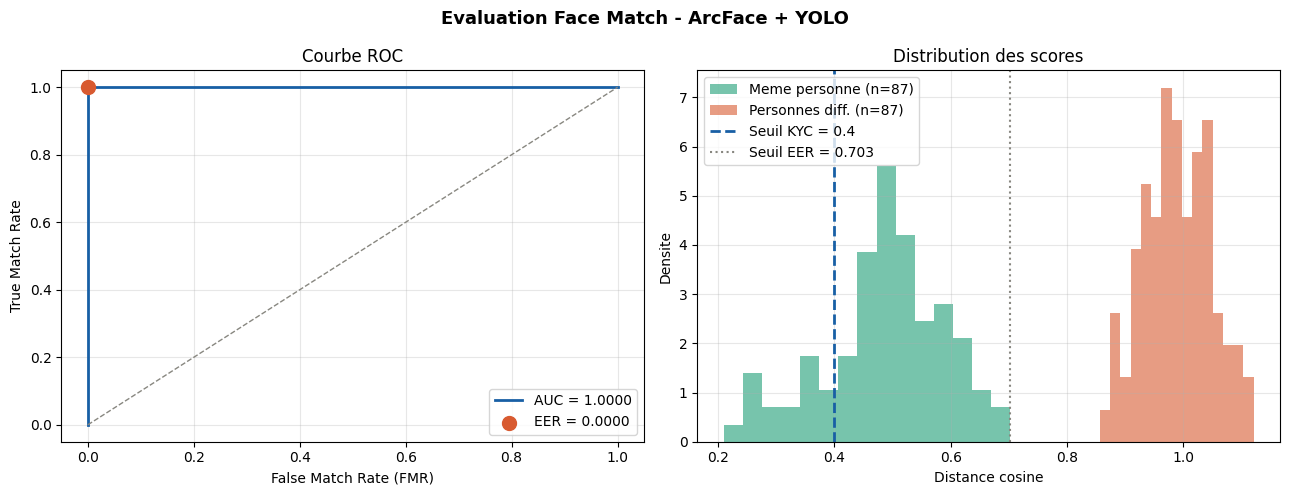

In [44]:
df_paires  = pd.read_csv('./pairs.csv')
distances  = []
labels     = []
nb_erreurs = 0

print(f'Evaluation sur {len(df_paires)} paires avec seuil = {SEUIL_DECISION}...')

for _, ligne in tqdm(df_paires.iterrows(), total=len(df_paires)):
    try:
        img_s = pretraiter_image(ligne['selfie_path'])
        img_i = pretraiter_image(ligne['id_path'])
        emb_s = extraire_embedding(img_s)
        emb_i = extraire_embedding(img_i)
        res   = comparer_visages(emb_s, emb_i, seuil=SEUIL_DECISION)
        distances.append(res['distance'])
        labels.append(int(ligne['label']))
    except Exception:
        nb_erreurs += 1

distances = np.array(distances)
labels    = np.array(labels)
scores    = 1.0 - distances

print(f'Termine : {len(labels)} paires traitees, {nb_erreurs} ignorees')

# Calcul des metriques
auc              = roc_auc_score(labels, scores)
fpr, tpr, seuils = roc_curve(labels, scores)
fnr              = 1.0 - tpr
idx_eer          = np.nanargmin(np.abs(fpr - fnr))
eer              = float(np.mean([fpr[idx_eer], fnr[idx_eer]]))
seuil_eer        = float(1.0 - seuils[idx_eer])
predictions      = (distances < SEUIL_DECISION).astype(int)
accuracy         = float(np.mean(predictions == labels))
tn, fp, fn, tp   = confusion_matrix(labels, predictions).ravel()
fmr              = fp / (fp + tn) if (fp + tn) > 0 else 0.0
fnmr             = fn / (fn + tp) if (fn + tp) > 0 else 0.0

print(f"\n{'='*50}")
print(f'  RESULTATS - Seuil KYC strict = {SEUIL_DECISION}')
print(f"{'='*50}")
print(f'  AUC-ROC  : {auc:.4f}   (performance globale du modele)')
print(f'  EER      : {eer:.4f}   (seuil optimal du modele = {seuil_eer:.4f})')
print(f'  Accuracy : {accuracy:.4f}   (au seuil strict {SEUIL_DECISION})')
print(f'  FMR      : {fmr:.4f}   (faux match - imposteur accepte)')
print(f'  FNMR     : {fnmr:.4f}   (faux non-match - rejet volontaire par securite)')
print(f"{'='*50}")
print(f'\n  Analyse :')
print(f'  Le modele a un AUC de {auc:.4f} et un EER de {eer:.4f},')
print(f'  ce qui indique un seuil optimal de {seuil_eer:.4f} pour equilibrer FMR et FNMR.')
print(f'  En contexte KYC, on choisit volontairement le seuil strict {SEUIL_DECISION},')
print(f'  ce qui reduit le FMR a {fmr:.4f} au prix d un FNMR de {fnmr:.4f}.')
print(f'  Ce compromis securite/UX est standard dans les systemes de verification d identite.')

print('--- Classification Counts ---')
print(f'True Positives (TP - Correct Match): {tp}')
print(f'True Negatives (TN - Correct No Match): {tn}')
print(f'False Positives (FP - Impostor Accepted): {fp}')
print(f'False Negatives (FN - True Person Rejected): {fn}')
print('---------------------------')

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='#185FA5', lw=2, label=f'AUC = {auc:.4f}')
axes[0].plot([0, 1], [0, 1], '--', color='#888780', lw=1)
axes[0].scatter([fpr[idx_eer]], [tpr[idx_eer]], color='#D85A30', s=100, zorder=5, label=f'EER = {eer:.4f}')
axes[0].set_xlabel('False Match Rate (FMR)')
axes[0].set_ylabel('True Match Rate')
axes[0].set_title('Courbe ROC')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].hist(distances[labels==1], bins=15, alpha=0.6, color='#1D9E75',
             label=f'Meme personne (n={int(labels.sum())})', density=True)
axes[1].hist(distances[labels==0], bins=15, alpha=0.6, color='#D85A30',
             label=f'Personnes diff. (n={int((labels==0).sum())})', density=True)
axes[1].axvline(SEUIL_DECISION, color='#185FA5', lw=2, linestyle='--',
                label=f'Seuil KYC = {SEUIL_DECISION}')
axes[1].axvline(seuil_eer, color='#888780', lw=1.5, linestyle=':',
                label=f'Seuil EER = {seuil_eer:.3f}')
axes[1].set_xlabel('Distance cosine')
axes[1].set_ylabel('Densite')
axes[1].set_title('Distribution des scores')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evaluation Face Match - ArcFace + YOLO', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Explication des résultats de classification

Pour comprendre en détail les performances du modèle, nous examinons les métriques suivantes :

-   **Vrais Positifs (TP)** : Le nombre de paires positives (même personne) que le modèle a correctement classées comme positives (MATCH).
-   **Vrais Négatifs (TN)** : Le nombre de paires négatives (personnes différentes) que le modèle a correctement classées comme négatives (NO MATCH).
-   **Faux Positifs (FP)** : Également appelées erreurs de type I, ce sont des paires négatives que le modèle a incorrectement classées comme positives (imposteur accepté).
-   **Faux Négatifs (FN)** : Également appelées erreurs de type II, ce sont des paires positives que le modèle a incorrectement classées comme négatives (personne réelle rejetée).